In [1]:
import pandas as pd 
df=pd.read_csv("../Data/final/environment_data.csv")

In [2]:
def detect_outliers_iqr(df, city=None):
    if city is not None:
        df = df[df["City"] == city]
    
    outlier_summary = []
    outlier_rows = pd.DataFrame()

    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        if col == "isWeekend" or col =="Electricity Consumption":
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outliers["Outlier_Feature"] = col   
        outlier_rows = pd.concat([outlier_rows, outliers])
        
        outlier_summary.append({
            "Feature": col,
            "Outliers_Count": len(outliers),
            "Lower_Bound": round(lower, 2),
            "Upper_Bound": round(upper, 2)
        })
    
    return pd.DataFrame(outlier_summary), outlier_rows



In [3]:
summary, outlier_rows = detect_outliers_iqr(df, city="Cairo")
print(summary.sort_values(by="Outliers_Count", ascending=False))

             Feature  Outliers_Count  Lower_Bound  Upper_Bound
9           Humidity              37        31.46        76.96
1               PM10              26         3.63        80.74
5                SO2              24         6.61        55.21
4                 CO              21        68.40       475.56
0              PM2.5              19         9.02        42.55
3                NO2               6        -0.66        60.76
10        Wind_speed               5         1.92        23.58
2                 O3               0        -5.19       131.65
7   Temperature_mean               0         3.89        43.14
6        Green_Space               0        53.00        53.00
8    Temperature_max               0         6.50        50.50
11          Pressure               0       985.89      1013.17


C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_28408\1207038265.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_28408\1207038265.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_28408\1207038265.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

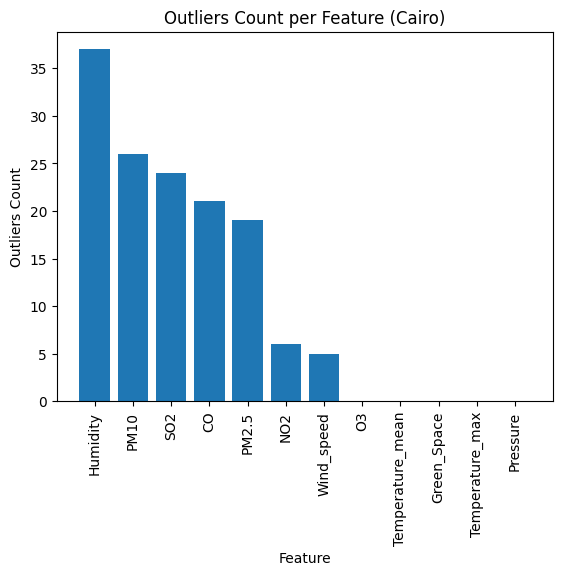

In [4]:
import matplotlib.pyplot as plt

summary_sorted = summary.sort_values(by="Outliers_Count", ascending=False)

plt.figure()
plt.bar(summary_sorted["Feature"], summary_sorted["Outliers_Count"])
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Outliers Count")
plt.title("Outliers Count per Feature (Cairo)")
plt.show()

##insight 1

The outlier analysis shows that Humidity has the highest variability among all features, followed by PM10, PM2.5, SO2, and CO. This pattern suggests a possible relationship between atmospheric humidity and air pollution levels in Cairo. High humidity may allow particulate matter to remain suspended in the air for longer periods and can contribute to the formation of secondary pollutants. In contrast, Temperature and Pressure showed no significant outliers, indicating relatively stable weather conditions. This suggests that fluctuations in air quality are more likely driven by pollution sources such as traffic and industrial activities rather than by temperature changes alone.


In [5]:
outlier_rows["Date"] = pd.to_datetime(outlier_rows["Date"])

In [6]:
outlier_rows["Date"].dt.month.value_counts()

Date
12    33
1     22
5     16
11    15
2     11
3     11
6      9
4      8
9      8
10     4
8      1
Name: count, dtype: int64

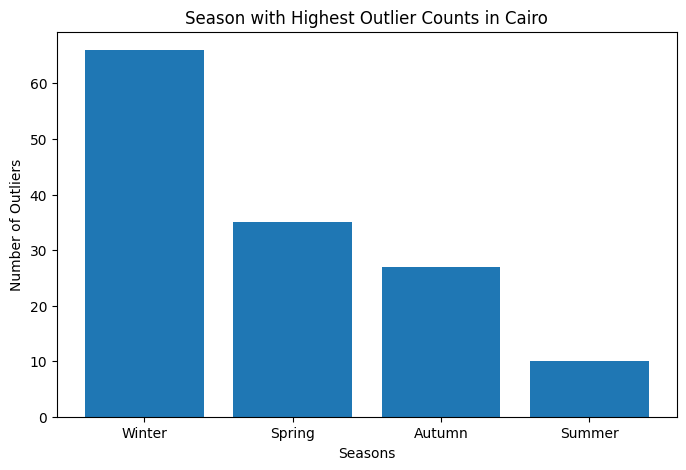

In [14]:
season_outliers = outlier_rows["Season"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(season_outliers.index.astype(str), season_outliers.values)

plt.xlabel("Seasons")
plt.ylabel("Number of Outliers")
plt.title("Season with Highest Outlier Counts in Cairo")

plt.show()

Winter had the highest number of outliers in Cairo, while summer had the lowest.

In [8]:
z=outlier_rows["isWeekend"].value_counts()
z

isWeekend
0    90
1    48
Name: count, dtype: int64

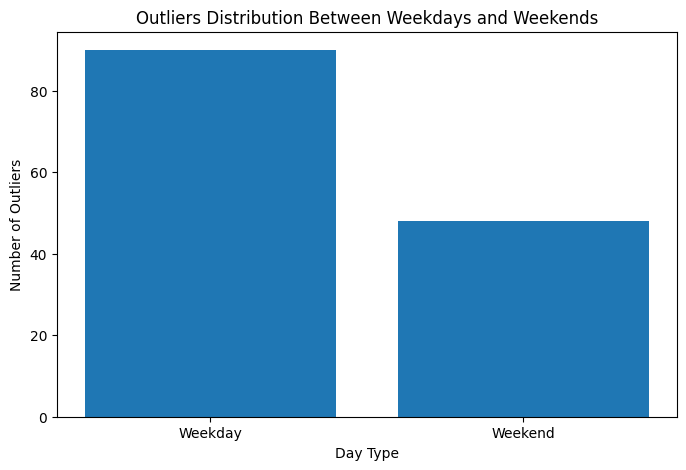

In [9]:
plt.figure(figsize=(8,5))

plt.bar(z.index.astype(str), z.values)

plt.xlabel("Day Type")
plt.ylabel("Number of Outliers")
plt.title("Outliers Distribution Between Weekdays and Weekends")

plt.xticks([0,1], ["Weekday", "Weekend"])

plt.show()

Severe pollution events in Cairo appear to be more strongly associated with regular working days and daily human activities rather than weekends or holiday periods.

In [10]:
normal_rows = df[~df.index.isin(outlier_rows.index)]

outliers_mean = outlier_rows.mean(numeric_only=True)
normal_mean = normal_rows.mean(numeric_only=True)

comparison = pd.DataFrame({
    "Outliers": outliers_mean,
    "Normal": normal_mean
})

comparison

,Outliers,Normal
PM2.5,3.742464e+01,1.991172e+01
PM10,7.996416e+01,3.583327e+01
O3,4.410356e+01,5.483431e+01
NO2,4.182107e+01,3.291811e+01
CO,3.838454e+02,3.378126e+02
SO2,4.818270e+01,1.344622e+01
Green_Space,5.300000e+01,1.069172e+02
Temperature_mean,2.221610e+01,1.891910e+01
Temperature_max,2.681159e+01,2.312946e+01
Humidity,4.876676e+01,6.514026e+01


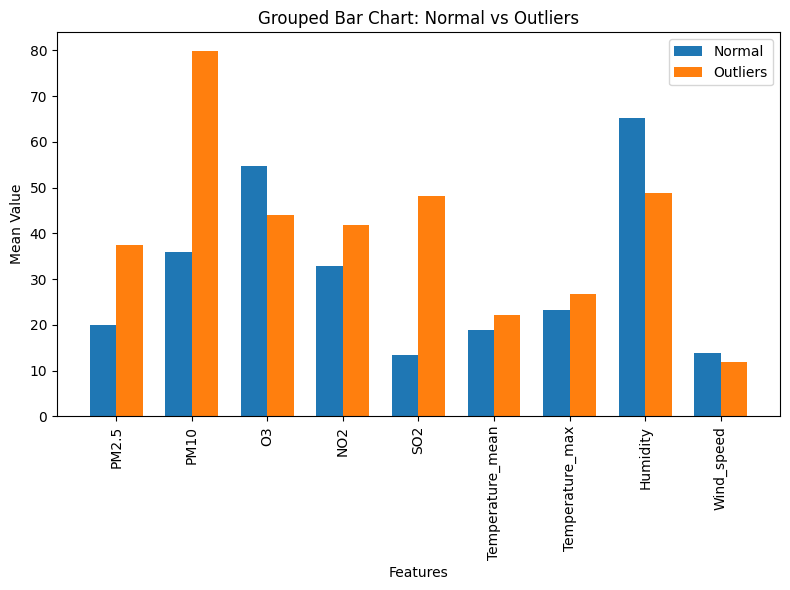

In [11]:
import numpy as np
compare = comparison.drop(["Pressure", "isWeekend","CO","Electricity Consumption","Green_Space"])
features = compare.index

x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(
    x - width/2,
    compare["Normal"],
    width=width,
    label="Normal"
)

plt.bar(
    x + width/2,
    compare["Outliers"],
    width=width,
    label="Outliers"
)

plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")

plt.legend()

plt.tight_layout()

plt.show()

The comparison between normal and outlier observations shows that outlier periods are associated with noticeably higher concentrations of pollutants such as PM10, PM2.5, SO2, and NO2 compared to normal conditions. These abnormal events also tend to occur under lower wind speed conditions, which may reduce air circulation and allow pollutants to remain concentrated in the atmosphere for longer periods. Overall, the results suggest that extreme pollution episodes in Cairo are influenced by both increased pollutant levels and unfavorable atmospheric conditions.


In [12]:
others= comparison.loc[["Pressure","CO"],:]

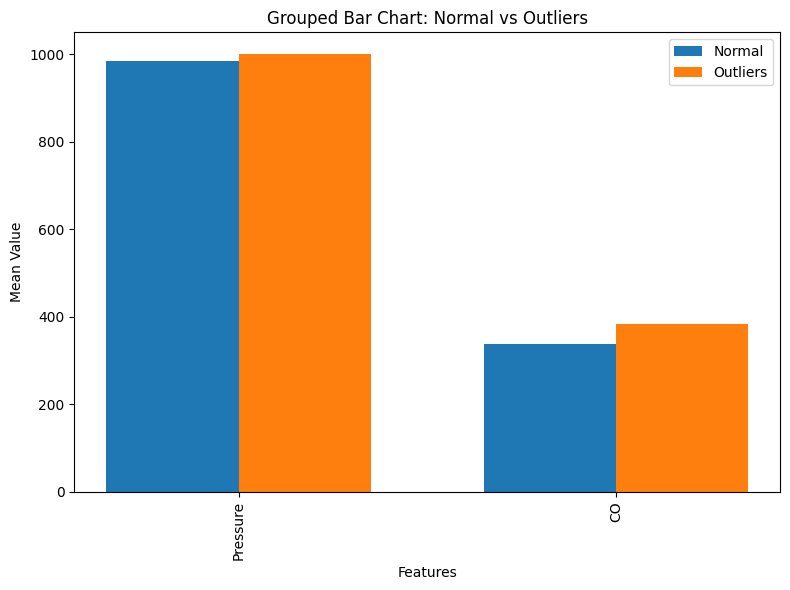

In [13]:
plt.figure(figsize=(8,6))
features=others.index
x=np.arange(len(features))
width=0.35
plt.bar(
    x-width/2,
    others["Normal"],
    width=width,
    label="Normal"
)
plt.bar(
    x+width/2,
    others["Outliers"],
    width=width,
    label="Outliers"
)
plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")
plt.legend()
plt.tight_layout()
plt.show()

The comparison between normal and outlier observations shows only a slight increase in Pressure and CO levels during outlier periods. This suggests that while these features may contribute to abnormal environmental conditions, their variations are relatively small compared to other pollution indicators such as PM10 and SO2, which showed much stronger differences between normal and outlier events.
